In [9]:
!pip -q install google-cloud-pubsub google-cloud-bigquery

In [13]:
import os

SOURCE_PROJECT_ID = "paul-leroy"
LAB_PROJECT_ID = "qwiklabs-gcp-04-af615cbd429c"
TOPIC_ID = "flight-transponder"
SUBSCRIPTION_ID = "flight-transponder-sub"

BQ_PROJECT_ID = LAB_PROJECT_ID
BQ_DATASET = "flight_streaming"
BQ_TABLE = "transponder_messages"
BQ_LOCATION = "US"

In [14]:
dataset_id = f"{BQ_PROJECT_ID}.{BQ_DATASET}"
table_id = f"{BQ_PROJECT_ID}.{BQ_DATASET}.{BQ_TABLE}"
print(dataset_id, table_id)

qwiklabs-gcp-04-af615cbd429c.flight_streaming qwiklabs-gcp-04-af615cbd429c.flight_streaming.transponder_messages


In [15]:
from google.cloud import pubsub_v1
from google.api_core.exceptions import AlreadyExists

subscriber = pubsub_v1.SubscriberClient()

topic_path = f"projects/{SOURCE_PROJECT_ID}/topics/{TOPIC_ID}"
sub_path = f"projects/{LAB_PROJECT_ID}/subscriptions/{SUBSCRIPTION_ID}"

try:
    subscriber.create_subscription(name=sub_path, topic=topic_path)
except AlreadyExists:
    pass

print("Topic:", topic_path)
print("Subscription:", sub_path)

Topic: projects/paul-leroy/topics/flight-transponder
Subscription: projects/qwiklabs-gcp-04-af615cbd429c/subscriptions/flight-transponder-sub


In [18]:
from google.cloud import bigquery
from google.api_core.exceptions import NotFound

bq = bigquery.Client(project=LAB_PROJECT_ID)

schema = [
    bigquery.SchemaField("MT", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("TT", "INT64", mode="NULLABLE"),
    bigquery.SchemaField("SID", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("AID", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("Hex", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("FID", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("DMG", "DATE", mode="NULLABLE"),
    bigquery.SchemaField("TMG", "TIME", mode="NULLABLE"),
    bigquery.SchemaField("DML", "DATE", mode="NULLABLE"),
    bigquery.SchemaField("TML", "TIME", mode="NULLABLE"),
    bigquery.SchemaField("CS", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("Alt", "INT64", mode="NULLABLE"),
    bigquery.SchemaField("GS", "INT64", mode="NULLABLE"),
    bigquery.SchemaField("Trk", "INT64", mode="NULLABLE"),
    bigquery.SchemaField("Lat", "FLOAT64", mode="NULLABLE"),
    bigquery.SchemaField("Lng", "FLOAT64", mode="NULLABLE"),
    bigquery.SchemaField("VR", "INT64", mode="NULLABLE"),
    bigquery.SchemaField("Sq", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("Alrt", "INT64", mode="NULLABLE"),
    bigquery.SchemaField("Emer", "INT64", mode="NULLABLE"),
    bigquery.SchemaField("SPI", "INT64", mode="NULLABLE"),
    bigquery.SchemaField("Gnd", "INT64", mode="NULLABLE"),
]

dataset_id = f"{LAB_PROJECT_ID}.{BQ_DATASET}"
table_id = f"{LAB_PROJECT_ID}.{BQ_DATASET}.{BQ_TABLE}"

# Create dataset if missing
try:
    bq.get_dataset(dataset_id)
except NotFound:
    ds = bigquery.Dataset(dataset_id)
    ds.location = BQ_LOCATION
    bq.create_dataset(ds)

# Create table if missing
try:
    bq.get_table(table_id)
except NotFound:
    tbl = bigquery.Table(table_id, schema=schema)
    bq.create_table(tbl)

print("Ready:", table_id)

Ready: qwiklabs-gcp-04-af615cbd429c.flight_streaming.transponder_messages


In [19]:
from google.cloud import pubsub_v1
from google.api_core.exceptions import AlreadyExists
from datetime import datetime
import time

subscriber = pubsub_v1.SubscriberClient()

topic_path = subscriber.topic_path(LAB_PROJECT_ID, TOPIC_ID)
sub_path = subscriber.subscription_path(LAB_PROJECT_ID, SUBSCRIPTION_ID)

# Create subscription if missing
try:
    subscriber.create_subscription(name=sub_path, topic=topic_path)
except AlreadyExists:
    pass

FIELDS = ["MT","TT","SID","AID","Hex","FID","DMG","TMG","DML","TML","CS","Alt","GS","Trk","Lat","Lng","VR","Sq","Alrt","Emer","SPI","Gnd"]

def _to_int(x):
    x = (x or "").strip()
    return int(x) if x != "" else None

def _to_float(x):
    x = (x or "").strip()
    return float(x) if x != "" else None

def _to_date_yyyy_mm_dd_slash(x):
    x = (x or "").strip()
    if x == "":
        return None
    # input like 2025/04/15
    return datetime.strptime(x, "%Y/%m/%d").date().isoformat()

def _to_time_hh_mm_ss_frac(x):
    x = (x or "").strip()
    if x == "":
        return None
    # input like 00:43:07.127 (milliseconds) -> pad to microseconds
    if "." in x:
        base, frac = x.split(".", 1)
        frac = (frac + "000000")[:6]
        return f"{base}.{frac}"
    return x

def parse_row(csv_line: str):
    parts = csv_line.strip().split(",")
    if len(parts) < 22:
        return None
    parts = parts[:22]

    row = dict(zip(FIELDS, parts))

    # Type conversions
    row["TT"] = _to_int(row["TT"])
    row["DMG"] = _to_date_yyyy_mm_dd_slash(row["DMG"])
    row["DML"] = _to_date_yyyy_mm_dd_slash(row["DML"])
    row["TMG"] = _to_time_hh_mm_ss_frac(row["TMG"])
    row["TML"] = _to_time_hh_mm_ss_frac(row["TML"])

    for k in ["Alt","GS","Trk","VR","Alrt","Emer","SPI","Gnd"]:
        row[k] = _to_int(row[k])

    row["Lat"] = _to_float(row["Lat"])
    row["Lng"] = _to_float(row["Lng"])

    # Empty strings -> None for STRING columns (optional, but cleaner)
    for k in ["MT","SID","AID","Hex","FID","CS","Sq"]:
        v = (row.get(k) or "").strip()
        row[k] = v if v != "" else None

    return row

def stream_for_seconds(seconds=180, max_messages=200):
    end = time.time() + seconds
    inserted = 0

    while time.time() < end:
        resp = subscriber.pull(request={"subscription": sub_path, "max_messages": max_messages}, timeout=10)
        if not resp.received_messages:
            continue

        rows = []
        ack_ids = []

        for rm in resp.received_messages:
            ack_ids.append(rm.ack_id)
            try:
                line = rm.message.data.decode("utf-8", errors="replace")
                row = parse_row(line)
                if row:
                    rows.append(row)
            except Exception:
                # skip bad messages but still ack to avoid infinite redelivery
                pass

        # Insert to BigQuery (streaming insert)
        if rows:
            errors = bq.insert_rows_json(table_id, rows)
            if errors:
                print("BigQuery insert errors (sample):", errors[:1])
            else:
                inserted += len(rows)

        # Ack messages
        subscriber.acknowledge(request={"subscription": sub_path, "ack_ids": ack_ids})

    return inserted

inserted = stream_for_seconds(seconds=180)  # run “for a few minutes”
print("Inserted rows:", inserted)

Inserted rows: 82581


In [20]:
count_sql = f"SELECT COUNT(*) AS n FROM `{table_id}`"
for row in bq.query(count_sql).result():
    print("Row count:", row["n"])

Row count: 82581


In [23]:
geoviz_sql = f"""
SELECT
  ST_GEOGPOINT(Lng, Lat) AS geom,
  CS,
  Hex,
  Alt,
  GS,
  DMG,
  TMG
FROM `{table_id}`
WHERE Lat IS NOT NULL AND Lng IS NOT NULL
"""
job = bq.query(geoviz_sql)
df = job.to_dataframe()
df.head()

,geom,CS,Hex,Alt,GS,DMG,TMG
0,POINT(-2.013931 51.806356),None,A8B9B3,32025,<NA>,2026-03-27,10:53:29.543000
1,POINT(0.89301 51.515717),None,484445,34725,<NA>,2026-03-27,10:53:32.142000
2,POINT(-3.2982 51.288254),None,341646,16000,<NA>,2026-03-27,10:53:38.695000
3,POINT(-3.296762 51.917523),None,4D222A,34000,<NA>,2026-03-27,10:53:31.531000
4,POINT(-0.438859 51.826447),None,406E69,21725,<NA>,2026-03-27,10:53:33.510000


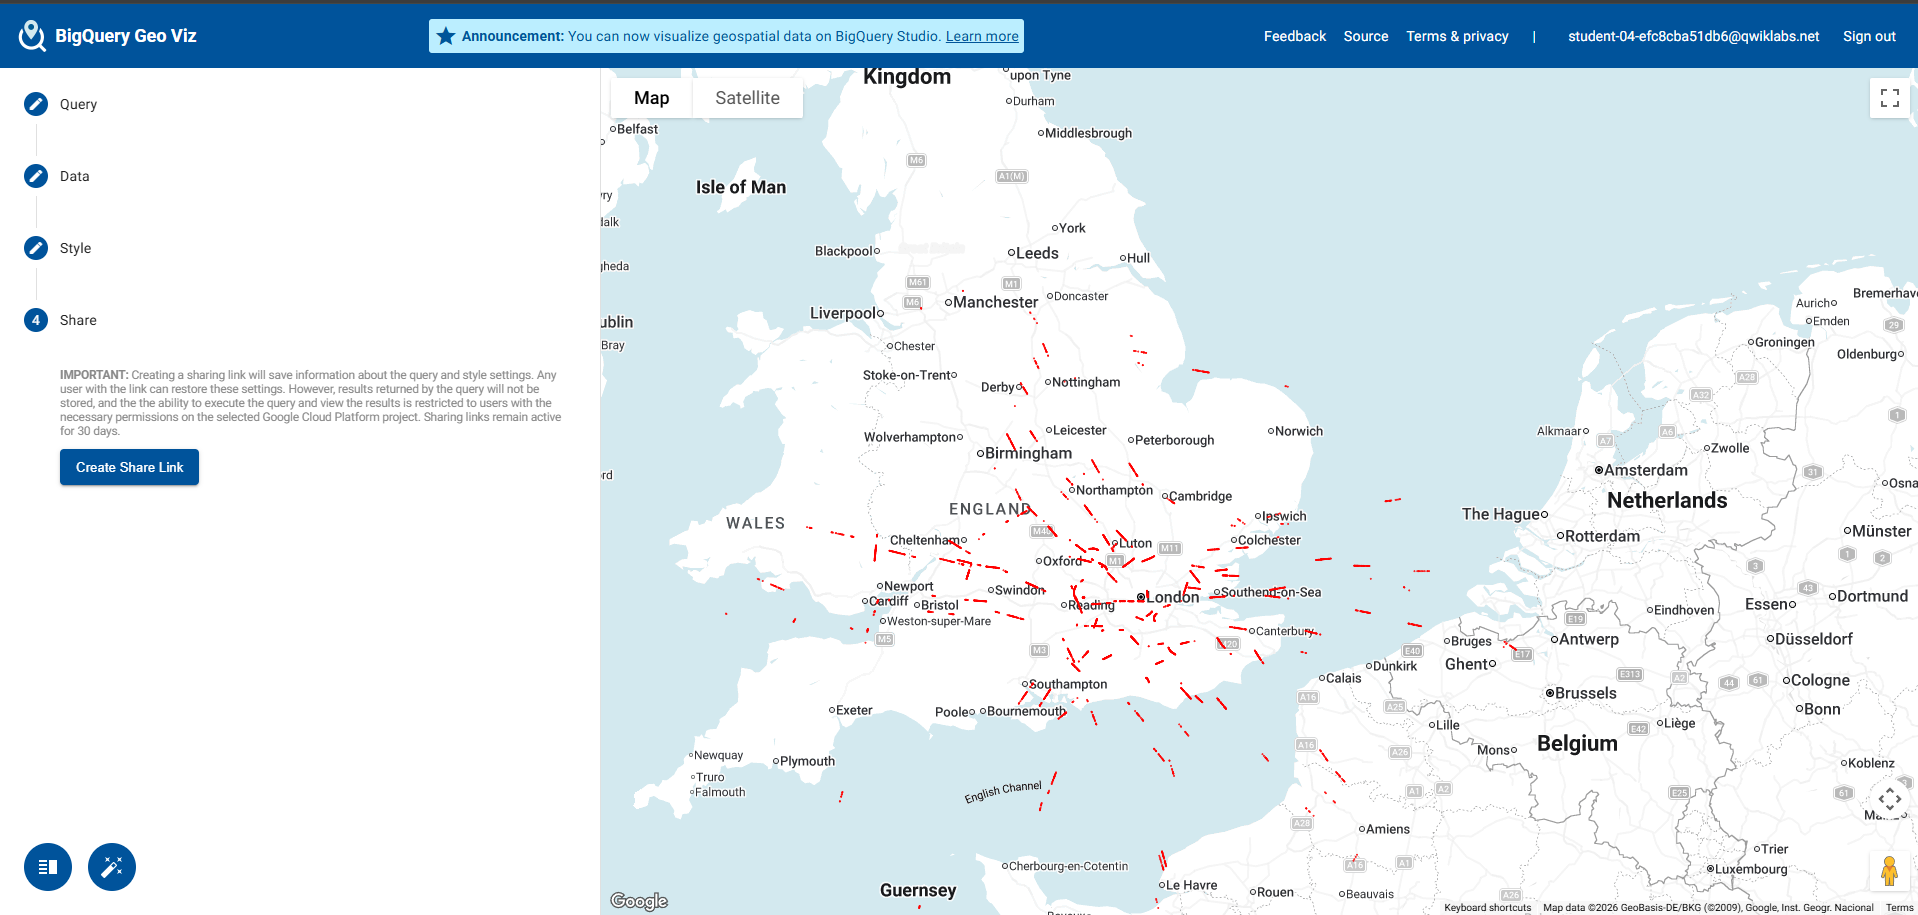